# 09 Playlist EDA

This notebook explores playlist-level patterns in the Spotify dataset.

The analysis focuses on:
- playlist sizes
- most common playlists
- popularity differences between playlists
- audio-feature differences across playlists
- how playlists may support recommendation logic

## 1. Load Data

In [1]:
from pathlib import Path
import sys
import warnings

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from config.paths import DUCKDB_PATH

con = duckdb.connect(DUCKDB_PATH)

In [2]:
tracks = con.execute("""
    SELECT *
    FROM tracks
""").df()

tracks.shape

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(101939, 32)

In [3]:
tracks[["name", "playlist", "popularity"]].head()

,name,playlist,popularity
0,Blood,Hipsteribrunssi,28.0
1,The Ugly Duckling,Animal Stories,31.0
2,Jimmy Launches His Own Range Of Greetings Cards,Best Of British Comedy,31.0
3,The Crime At Pickets Mill,Short Stories,14.0
4,Setup + Punchline = Joke,Best Of British Comedy,32.0


## 2. Playlist Overview

In [4]:
playlist_overview = pd.DataFrame({
    "total_tracks": [len(tracks)],
    "unique_playlists": [tracks["playlist"].nunique()],
    "missing_playlist_values": [tracks["playlist"].isna().sum()]
})

playlist_overview

,total_tracks,unique_playlists,missing_playlist_values
0,101939,3800,0


In [5]:
tracks["playlist"].value_counts().head(20)

playlist
Comedy Top Tracks                  129
Hörspielzeit: Feuerwehrmann Sam    100
Hörspielzeit: Benjamin Blümchen    100
Spaß mit Freunden: Hörspiele       100
The Romantics                      100
Hörspielzeit: TKKG                 100
Hörspielzeit: Die drei !!!         100
Learn Russian                      100
Hörspielzeit: Bibi & Tina          100
Learn German                       100
Emily Dickinson                    100
Hörspielzeit Leo Lausemaus         100
Hörspielzeit: Die drei ??? Kids    100
Hörspielzeit: Bibi Blocksberg      100
Learn Chinese                      100
Sing meinen Song                   100
Sleep Sounds                       100
Hörspielzeit: Tabaluga             100
Hawaii Reggae                      100
Learn French                       100
Name: count, dtype: int64

## 3. Most Common Playlists

In [6]:
top_playlists = (
    tracks["playlist"]
    .value_counts()
    .head(20)
    .reset_index()
)

top_playlists.columns = [
    "playlist",
    "number_of_tracks"
]

top_playlists

,playlist,number_of_tracks
0,Comedy Top Tracks,129
1,Hörspielzeit: Feuerwehrmann Sam,100
2,Hörspielzeit: Benjamin Blümchen,100
3,Spaß mit Freunden: Hörspiele,100
4,The Romantics,100
5,Hörspielzeit: TKKG,100
6,Hörspielzeit: Die drei !!!,100
7,Learn Russian,100
8,Hörspielzeit: Bibi & Tina,100
9,Learn German,100


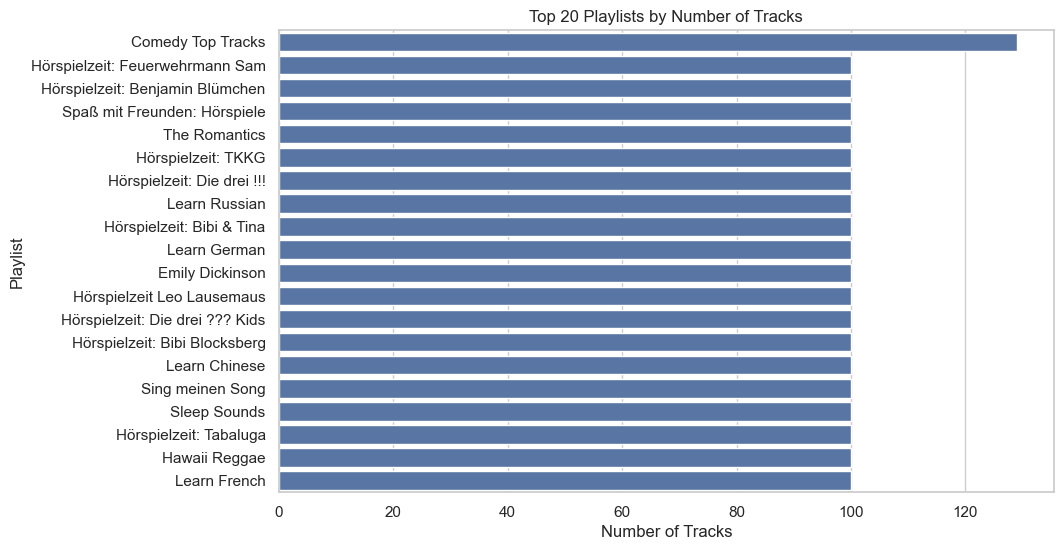

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_playlists,
    x="number_of_tracks",
    y="playlist"
)

plt.title("Top 20 Playlists by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Playlist")

plt.show()

## 4. Playlist Popularity Analysis

In [8]:
playlist_popularity = (
    tracks.groupby("playlist")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

playlist_popularity.columns = [
    "playlist",
    "average_popularity"
]

playlist_popularity.head(15)

,playlist,average_popularity
0,United States Top 50,93.000000
1,Mexico Top 50,87.041667
2,Syliin,86.000000
3,A1 Hip-Hop,81.000000
4,Baila Reggaeton,80.357143
5,Mega Hit Mix,79.500000
6,Éxitos Chile,79.333333
7,Hip Hop Mixtape,79.000000
8,Brazil Top 50,78.304348
9,Colombia Top 50,78.000000


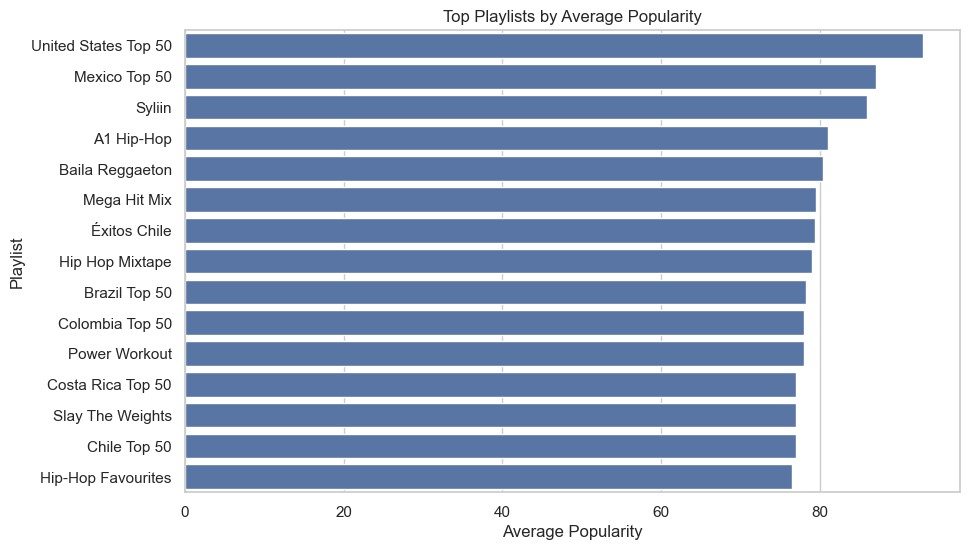

In [9]:
top_popular_playlists = playlist_popularity.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_popular_playlists,
    x="average_popularity",
    y="playlist"
)

plt.title("Top Playlists by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Playlist")

plt.show()

## 5. Playlist Audio Feature Profiles

In [10]:
audio_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness"
]

In [11]:
playlist_audio_profiles = (
    tracks.groupby("playlist")[audio_features]
    .mean()
    .reset_index()
)

playlist_audio_profiles.head()

,playlist,danceability,energy,valence,acousticness,speechiness
0,#BicampeãoDaFé,0.614375,0.657125,0.639338,0.374917,0.144444
1,#ChegaDeAssédio,0.600250,0.610812,0.547438,0.417687,0.163763
2,#FHR2018,0.662600,0.643250,0.535490,0.233389,0.088890
3,#LilleFredag,0.697667,0.795667,0.592667,0.153767,0.074333
4,#ThrowbackThursday,0.550333,0.647000,0.545976,0.287675,0.048888


## 6. Comparing Playlist Styles

In [12]:
selected_playlists = [
    "Sleep Sounds",
    "Comedy Top Tracks",
    "Hawaii Reggae",
    "Learn French",
    "The Romantics"
]

comparison_df = playlist_audio_profiles[
    playlist_audio_profiles["playlist"].isin(selected_playlists)
]

comparison_df

,playlist,danceability,energy,valence,acousticness,speechiness
675,Comedy Top Tracks,0.553395,0.825682,0.364460,0.780588,0.865414
1334,Hawaii Reggae,0.760030,0.602310,0.740580,0.195605,0.099724
1767,Learn French,0.597890,0.065233,0.307512,0.615308,0.592304
2738,Sleep Sounds,0.174376,0.339100,0.044595,0.007541,0.058798
3049,The Romantics,0.664150,0.122728,0.397950,0.762038,0.707390


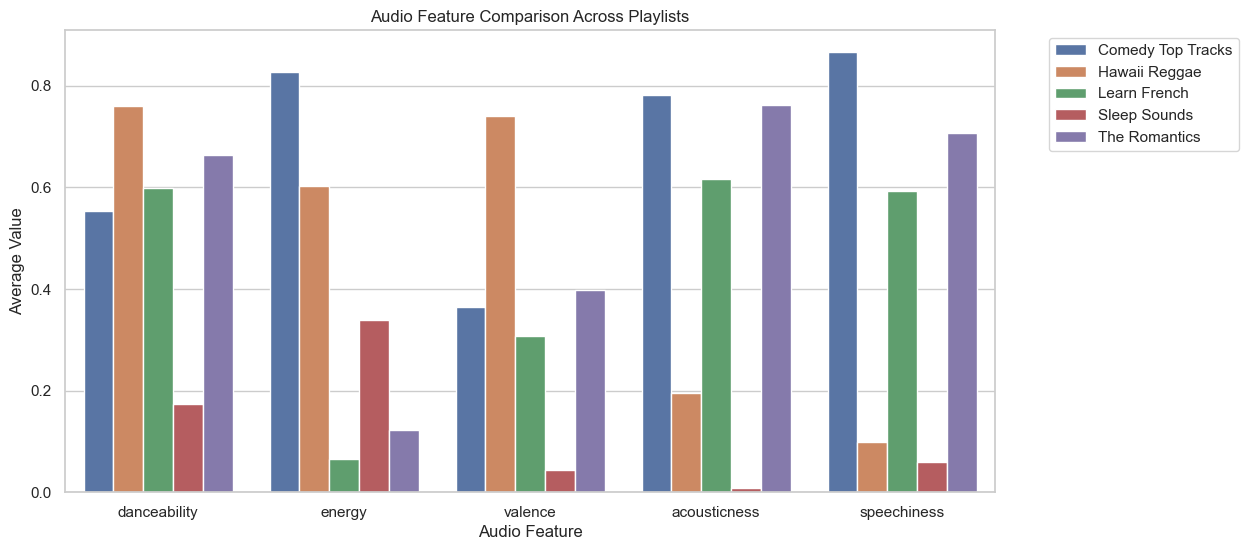

In [13]:
comparison_melted = comparison_df.melt(
    id_vars="playlist",
    value_vars=audio_features,
    var_name="feature",
    value_name="value"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_melted,
    x="feature",
    y="value",
    hue="playlist"
)

plt.title("Audio Feature Comparison Across Playlists")
plt.xlabel("Audio Feature")
plt.ylabel("Average Value")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

## 7. Playlist Size Distribution

In [14]:
playlist_sizes = (
    tracks.groupby("playlist")
    .size()
    .reset_index(name="track_count")
)

playlist_sizes.head()

,playlist,track_count
0,#BicampeãoDaFé,16
1,#ChegaDeAssédio,16
2,#FHR2018,80
3,#LilleFredag,3
4,#ThrowbackThursday,42


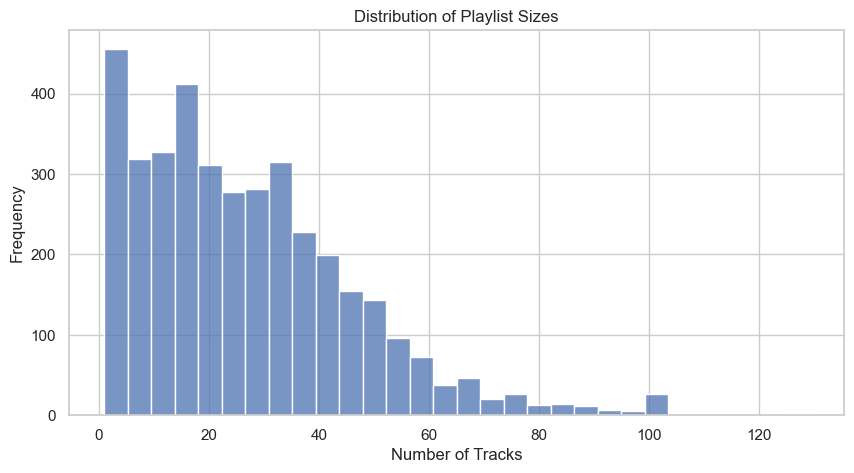

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    playlist_sizes["track_count"],
    bins=30
)

plt.title("Distribution of Playlist Sizes")
plt.xlabel("Number of Tracks")
plt.ylabel("Frequency")

plt.show()

## 8. Playlist Similarity Analysis

In [16]:
playlist_similarity_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness"
]

In [17]:
playlist_feature_matrix = (
    tracks.groupby("playlist")[playlist_similarity_features]
    .mean()
)

playlist_feature_matrix.head()

,danceability,energy,valence,acousticness,speechiness
playlist,,,,,
#BicampeãoDaFé,0.614375,0.657125,0.639338,0.374917,0.144444
#ChegaDeAssédio,0.600250,0.610812,0.547438,0.417687,0.163763
#FHR2018,0.662600,0.643250,0.535490,0.233389,0.088890
#LilleFredag,0.697667,0.795667,0.592667,0.153767,0.074333
#ThrowbackThursday,0.550333,0.647000,0.545976,0.287675,0.048888


In [19]:
from sklearn.metrics.pairwise import cosine_similarity

playlist_similarity_matrix = cosine_similarity(
    playlist_feature_matrix
)

playlist_similarity_df = pd.DataFrame(
    playlist_similarity_matrix,
    index=playlist_feature_matrix.index,
    columns=playlist_feature_matrix.index
)

playlist_similarity_df.iloc[:5, :5]

playlist,#BicampeãoDaFé,#ChegaDeAssédio,#FHR2018,#LilleFredag,#ThrowbackThursday
playlist,,,,,
#BicampeãoDaFé,1.000000,0.996566,0.988231,0.972335,0.994158
#ChegaDeAssédio,0.996566,1.000000,0.981758,0.959436,0.987023
#FHR2018,0.988231,0.981758,1.000000,0.993386,0.993393
#LilleFredag,0.972335,0.959436,0.993386,1.000000,0.986654
#ThrowbackThursday,0.994158,0.987023,0.993393,0.986654,1.000000


## 9. Most Similar Playlists

In [20]:
playlist_pairs = []

playlists = playlist_similarity_df.index.tolist()

for i in range(len(playlists)):
    for j in range(i + 1, len(playlists)):
        playlist_pairs.append({
            "playlist_1": playlists[i],
            "playlist_2": playlists[j],
            "similarity_score": playlist_similarity_df.iloc[i, j]
        })

playlist_pairs_df = pd.DataFrame(playlist_pairs)

In [21]:
top_playlist_pairs = (
    playlist_pairs_df
    .sort_values("similarity_score", ascending=False)
    .head(10)
)

top_playlist_pairs

,playlist_1,playlist_2,similarity_score
6129904,Pop Internacional,Se on hitti!,1.000000
6180308,Popeando,Unwind 00s,0.999997
428861,A Breath of Fresh Éire,Pop PT,0.999996
6094279,Political Punks,Skate Park,0.999994
2259441,Club Acoustic,K-Power Vocals,0.999993
2802344,Desi Hip-Hop,Só as Minas,0.999993
587077,Acoustic Rock,The Pulse of Americana,0.999990
1931881,Chicas Indie,Zona Indie,0.999990
4195999,Heavy Metal,Heviä treeneihin,0.999989
2077694,Christian Kids Music,Evening Indie,0.999988


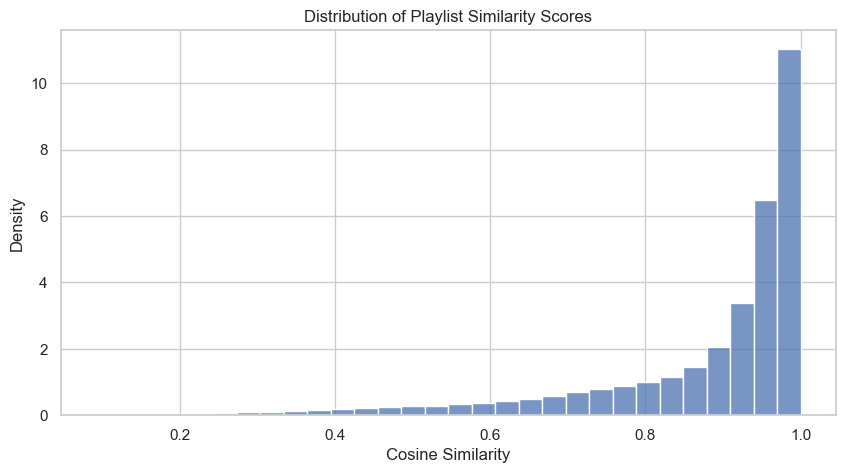

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    playlist_pairs_df["similarity_score"],
    bins=30,
    stat="density"
)

plt.title("Distribution of Playlist Similarity Scores")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")

plt.show()

## 10. Playlist Diversity

In [23]:
playlist_variability = (
    tracks.groupby("playlist")[playlist_similarity_features]
    .std()
    .mean(axis=1)
    .reset_index(name="average_feature_variability")
)

playlist_variability.head()

,playlist,average_feature_variability
0,#BicampeãoDaFé,0.174124
1,#ChegaDeAssédio,0.216798
2,#FHR2018,0.171494
3,#LilleFredag,0.114354
4,#ThrowbackThursday,0.202992


In [24]:
most_diverse_playlists = (
    playlist_variability
    .sort_values(
        "average_feature_variability",
        ascending=False
    )
    .head(15)
)

most_diverse_playlists

,playlist,average_feature_variability
2072,Netherlands Viral 50,0.323775
3485,Träna med fashionablefit,0.319473
1076,Fin de Semana Juntos,0.314589
1027,Family Party,0.311791
2370,Power 8 WHM,0.294911
488,Can You Deal?,0.293455
1930,Melody McCloskey Lady Day Playlist,0.292558
1243,Going on a Drive,0.291810
845,Diaper Time,0.289803
2146,Note to Self with Manoush Zomorodi,0.287938


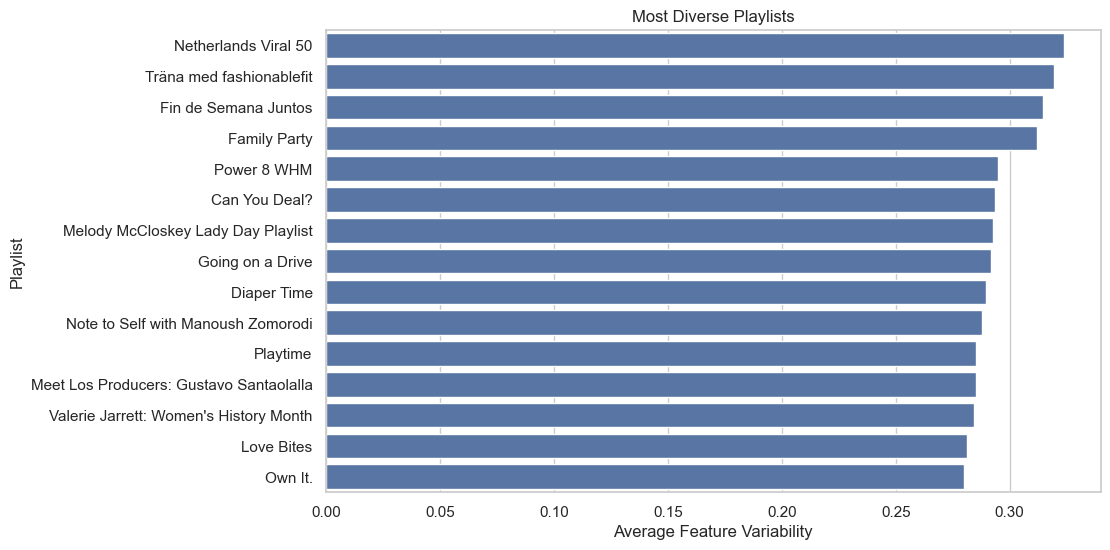

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=most_diverse_playlists,
    x="average_feature_variability",
    y="playlist"
)

plt.title("Most Diverse Playlists")
plt.xlabel("Average Feature Variability")
plt.ylabel("Playlist")

plt.show()

## 11. Recommender Implications

The playlist analysis shows that playlists capture meaningful listening patterns and audio characteristics.

Key findings:
- Playlists differ strongly in energy, danceability, speechiness, and acousticness
- Certain playlists are highly specialized (e.g. Sleep Sounds, Learn French)
- Popular playlists often contain energetic and highly danceable tracks
- Playlist similarity can later support content-based recommendation systems

These findings support the use of:
- cosine similarity
- nearest-neighbor recommenders
- embedding-based recommendation approaches
- clustering and latent-space modeling in future project phases

## 12. Save Playlist-Level Features

In [30]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness"
]

playlist_audio_features = (
    tracks
    .groupby("playlist")[feature_cols]
    .mean()
    .reset_index()
)

playlist_audio_features.head()

,playlist,danceability,energy,valence,acousticness,speechiness
0,#BicampeãoDaFé,0.614375,0.657125,0.639338,0.374917,0.144444
1,#ChegaDeAssédio,0.600250,0.610812,0.547438,0.417687,0.163763
2,#FHR2018,0.662600,0.643250,0.535490,0.233389,0.088890
3,#LilleFredag,0.697667,0.795667,0.592667,0.153767,0.074333
4,#ThrowbackThursday,0.550333,0.647000,0.545976,0.287675,0.048888


In [31]:
scaler = StandardScaler()

playlist_features_scaled = playlist_audio_features.copy()

playlist_features_scaled[feature_cols] = scaler.fit_transform(
    playlist_features_scaled[feature_cols]
)

playlist_features_scaled.head()

,playlist,danceability,energy,valence,acousticness,speechiness
0,#BicampeãoDaFé,0.135008,0.255596,0.821821,0.208793,0.290558
1,#ChegaDeAssédio,0.023010,0.019520,0.296023,0.380695,0.435045
2,#FHR2018,0.517387,0.184869,0.227666,-0.360033,-0.124936
3,#LilleFredag,0.795432,0.961804,0.554798,-0.680047,-0.233807
4,#ThrowbackThursday,-0.372783,0.203984,0.287662,-0.141848,-0.424115


In [32]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

playlist_audio_features.to_csv(
    processed_dir / "playlist_audio_features.csv",
    index=False
)

playlist_features_scaled.to_csv(
    processed_dir / "playlist_features_scaled.csv",
    index=False
)

print("Playlist-level datasets saved successfully.")

Playlist-level datasets saved successfully.


## Final Notes

The playlist analysis shows that playlists provide useful context beyond individual track features. Different playlists have clearly different average audio profiles, especially in terms of energy, danceability, acousticness, and speechiness.

The scaled playlist-level dataset can later be used for playlist similarity, clustering, or recommendation approaches that group tracks by listening context.

In [33]:
con.close()